# Tutorial: Adaptive Maximum Entropy Snapshot Sampling (AdaMESS)

This notebook demonstrates **AdaMESS**, the *adaptive* extension of MESS used for
memory-efficient reduced-basis generation. Where plain MESS **filters** an already
existing snapshot matrix, AdaMESS **decides where to compute the next full-order
snapshot** along a parameter axis — so it never has to store the dense uniform
sequence in the first place.

The method walks a 1-D parameter range $[s_\text{start}, s_\text{end}]$ and keeps a
sliding window of the most recent snapshots. From that window it forms

- a **recurrence / MESS keep-ratio** (how redundant is the local data?), and
- a **gradient brake** $\;\|P_{i+1}-P_i\|\;$ (how fast does the solution change?),

and combines them into a **symmetric step-size controller**: a single keep-ratio
exponent shrinks the step where the data is too diverse and grows it where the data
is redundant. A POD basis is then built directly from the sampled snapshots.

> **Reference** — S. Stroka et al., *Adaptive Maximum Entropy Snapshot Sampling for
> Memory Efficient Reduced-Basis Generation*, IEEE CEFC 2026.
> Builds on F. Kasolis and M. Clemens, *Maximum Entropy Snapshot Sampling for Reduced
> Basis Generation*, arXiv:2005.01280, 2020.

The full-order solver in this demo is a cheap **synthetic field** so the notebook
runs anywhere; in a real workflow you pass your own `solve(s) -> vector` (e.g. an
SPFD/FEM field solve at coil position `s`).

## 1. Imports

In [19]:
import numpy as np
import matplotlib.pyplot as plt

from mess import AdaMESS, build_pod_basis

ANTHRACITE = "#1F3A47"; WUP_GREEN = "#7AB51D"; AMBER = "#B07A2C"; STEEL = "#7A99AD"
plt.rcParams.update({
    "font.size": 12, "axes.edgecolor": ANTHRACITE, "axes.labelcolor": ANTHRACITE,
    "text.color": ANTHRACITE, "xtick.color": ANTHRACITE, "ytick.color": ANTHRACITE,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "legend.frameon": False,
})

## 2. A synthetic full-order solver

We mimic a field whose dominant feature — a Gaussian "hot spot" — travels through
the spatial domain as the parameter $s$ changes. The motion is **nonlinear in $s$**
(via $\tanh$): the field is almost static near the ends and changes rapidly in the
middle. This is exactly the regime where uniform sampling wastes solves in the quiet
regions and risks under-resolving the active one.

`solve(s)` returns a 200-dimensional vector — think of it as the discretized field on
a 1-D mesh. Swap this function for your own FOM solve to use AdaMESS for real.

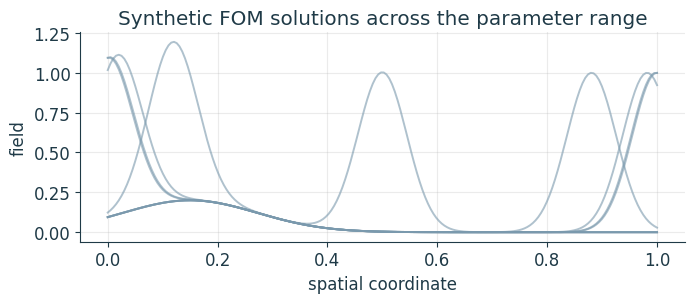

In [20]:
N_DOF = 200
x = np.linspace(0.0, 1.0, N_DOF)

# parameter axis in problem-like units (e.g. coil position in mm)
START, END = 0.0, 4000.0
SPAN = END - START

def solve(s):
    """Synthetic FOM: a Gaussian peak that travels nonlinearly with s.
    The motion is concentrated in the middle of the range (sharp tanh), so the
    field is almost static near both ends and changes fast in the centre --
    exactly where uniform sampling is wasteful and adaptive sampling pays off."""
    sn = (s - START) / SPAN                          # normalized in [0, 1]
    center = 0.5 * (1.0 + np.tanh(8.0 * (sn - 0.5))) # peak position in [0, 1]
    field  = np.exp(-((x - center) ** 2) / 0.004)
    field += 0.20 * np.exp(-((x - 0.15) ** 2) / 0.03)  # static secondary bump
    return field

# preview a few solutions across the range
fig, ax = plt.subplots(figsize=(7, 3.2))
for s in np.linspace(START, END, 9):
    ax.plot(x, solve(s), color=STEEL, alpha=0.6, lw=1.4)
ax.set_xlabel("spatial coordinate"); ax.set_ylabel("field")
ax.set_title("Synthetic FOM solutions across the parameter range")
plt.tight_layout(); plt.show()

## 3. Run AdaMESS

We sample the parameter range with two values of the target keep ratio
$\zeta$ (`target_keep`) and a fixed gradient-brake strength $\beta$ (`beta_grad`),
mirroring the CEFC configuration. Lower $\zeta$ ⇒ fewer snapshots kept per window
⇒ more aggressive thinning. The `solve` callable is the only problem-specific input.

In [21]:
BETA = 5.0
STEP_MIN  = 0.0008 * SPAN
STEP_MAX  = 0.10   * SPAN

runs = {}
for zeta in (0.9, 0.8):
    ada = AdaMESS(
        solve, start=START, end=END,
        target_keep=zeta, beta_keep=4.0, beta_grad=BETA,
        chunk_size=10, epsilon_percentile=10.0,
        step_min=STEP_MIN, step_max=STEP_MAX, step_init=STEP_MIN,
    )
    res = ada.run(variant_name=f"AdaMESS (zeta={zeta}, beta={BETA})")
    runs[zeta] = res
    print(f"zeta={zeta}: {res.n_fom_solves} full-order solves")

# uniform baseline at the same minimum step
uniform_positions = list(np.arange(START, END, STEP_MIN))
print(f"uniform baseline: {len(uniform_positions)} full-order solves")

zeta=0.9: 130 full-order solves
zeta=0.8: 527 full-order solves
uniform baseline: 1250 full-order solves


## 4. Where do the snapshots land?

The rug plots below show the sampled parameter positions for each strategy. AdaMESS
clusters its snapshots where the field changes fastest (the middle) and spreads them
out in the quiet end regions — whereas uniform sampling spends the same density
everywhere.

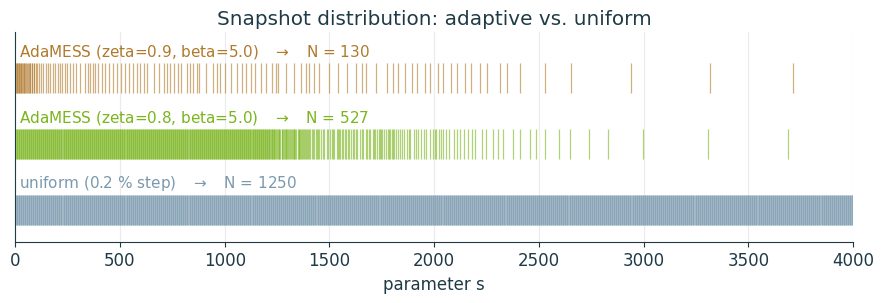

In [39]:
fig, ax = plt.subplots(figsize=(9, 3.2))
rows = [
    ("uniform (0.2 % step)", uniform_positions, STEEL,  0),
    (runs[0.8].variant,     runs[0.8].positions, WUP_GREEN, 1),
    (runs[0.9].variant,     runs[0.9].positions, AMBER, 2),
]
GAP = 1.2   # Abstand pro Reihe (statt 1.0)
for label, pos, color, row in rows:
    pos = np.asarray(pos, dtype=float)
    y = row * GAP
    ax.vlines(pos, y + 0.2, y + 0.75, color=color, lw=0.9, alpha=0.6)
    ax.text(START + 20.0, y + 0.8, rf"{label}   $\rightarrow$   N = {len(pos)}",
            color=color, fontsize=11, va="bottom")
ax.set_yticks([]); ax.set_xlabel("parameter s")
ax.set_ylim(-0.1, 2 * GAP + 1.3); ax.set_xlim(START, END)
ax.set_title("Snapshot distribution: adaptive vs. uniform")
plt.tight_layout(); plt.show()

## 5. Memory and compute benchmark

Memory of the snapshot matrix scales as $N \cdot \text{DoF} \cdot \text{bytes}$, and
the number of expensive FOM solves is just $N$. We report both **relative to the
uniform baseline** — the headline result of the method.

In [41]:
BYTES_PER_DOF = 16  # double complex in a real field problem

def memory_bytes(n):     return n * N_DOF * BYTES_PER_DOF
def fmt_mem(b):          return f"{b/1024**3:.2f} GB" if b >= 1024**3 else f"{b/1024**2:.1f} MB"

N_uni = len(uniform_positions)
strategies = [
    ("uniform sampling",  N_uni,                STEEL),
    (runs[0.8].variant,  runs[0.8].n_fom_solves, WUP_GREEN),
    (runs[0.90].variant,  runs[0.90].n_fom_solves, AMBER),
]

print(f"{'strategy':40s} {'N solves':>9s} {'memory':>10s} {'vs uniform':>11s}")
print("-" * 74)
for label, n, _ in strategies:
    print(f"{label:40s} {n:9d} {fmt_mem(memory_bytes(n)):>10s} "
          f"{100.0 * n / N_uni:9.1f} %")

strategy                                  N solves     memory  vs uniform
--------------------------------------------------------------------------
uniform sampling                              1250     3.8 MB     100.0 %
AdaMESS (zeta=0.8, beta=5.0)                   527     1.6 MB      42.2 %
AdaMESS (zeta=0.9, beta=5.0)                   130     0.4 MB      10.4 %


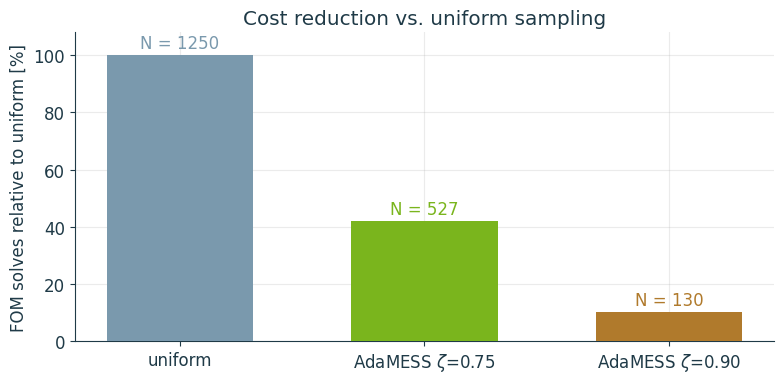

In [43]:
fig, ax = plt.subplots(figsize=(8, 4))
labels  = [s[0].split(" (")[0] if "(" not in s[0] else s[0] for s in strategies]
n_vals  = np.array([s[1] for s in strategies], dtype=float)
colors  = [s[2] for s in strategies]
rel     = 100.0 * n_vals / n_vals[0]

bars = ax.bar(range(len(strategies)), rel, color=colors, width=0.6, zorder=3)
for i, (b, n) in enumerate(zip(bars, n_vals)):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
            f"N = {int(n)}", ha="center", va="bottom", color=colors[i], fontsize=12)

ax.set_xticks(range(len(strategies)))
ax.set_xticklabels(["uniform", r"AdaMESS $\zeta$=0.75", r"AdaMESS $\zeta$=0.90"])
ax.set_ylabel("FOM solves relative to uniform [%]")
ax.set_ylim(0, 108)
ax.set_title("Cost reduction vs. uniform sampling")
plt.tight_layout(); plt.show()

## 6. POD basis from the sampled snapshots

A POD basis is built directly from the adaptively sampled snapshots via SVD. The
singular-value decay shows that the adaptive snapshots span essentially the same
subspace as the dense uniform set — at a fraction of the cost.

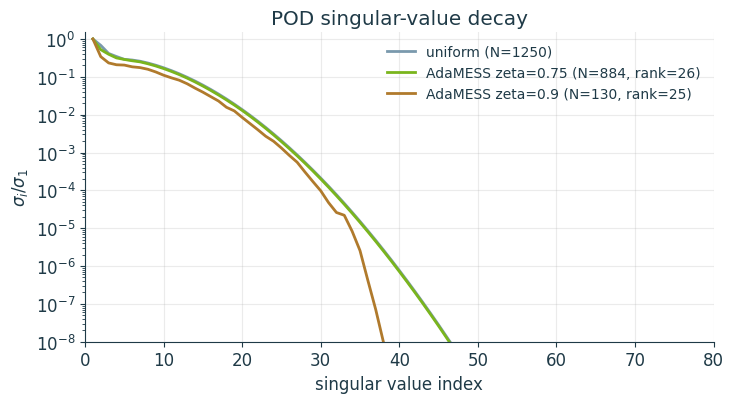

In [ ]:
# build the dense uniform snapshot matrix once, for reference
S_uniform = np.column_stack([solve(s) for s in uniform_positions])
_, sig_uniform = build_pod_basis(S_uniform, rank=None)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.semilogy(range(1, len(sig_uniform) + 1), sig_uniform / sig_uniform[0],
            color=STEEL, lw=2, label=f"uniform (N={N_uni})")

for zeta, color in ((0.75, WUP_GREEN), (0.90, AMBER)):
    res = runs[zeta]
    V, sig = build_pod_basis(res.snapshots, rank=None)
    ax.semilogy(range(1, len(sig) + 1), sig / sig[0], color=color, lw=2,
                label=f"AdaMESS zeta={zeta} (N={res.n_fom_solves}, rank={V.shape[1]})")

ax.set_xlabel("singular value index"); ax.set_ylabel(r"$\sigma_i / \sigma_1$")
ax.set_xlim(0, 80); ax.set_ylim(1e-8, 1.5); ax.legend(fontsize=10)
ax.set_title("POD singular-value decay")
plt.tight_layout(); plt.show()

## 7. Using AdaMESS on your own problem

```python
from mess import AdaMESS, build_pod_basis

def solve(s):
    # ... compute and return the full-order solution vector at parameter s ...
    return phi

ada = AdaMESS(solve, start=S0, end=S1, target_keep=0.85, beta_grad=1.0)
res = ada.run()                                    # adaptive snapshot generation
V, sigma = build_pod_basis(res.snapshots)          # POD basis from the samples
```

**Key knobs**

| Parameter | Role | Effect |
|-----------|------|--------|
| `target_keep` ($\zeta$) | MESS keep ratio | lower ⇒ fewer snapshots, more aggressive |
| `beta_keep` | keep-ratio exponent | higher ⇒ stronger reaction to redundancy |
| `beta_grad` ($\beta$) | gradient-brake strength | higher ⇒ stronger slow-down at fast changes |
| `chunk_size` | sliding-window length | larger ⇒ smoother, laggier adaptation |
| `step_min/step_max` | step bounds | safety rails (default 0.2 % / 5 % of span) |

`res.save(path)` / `SamplingResult.load(path)` persist a run to HDF5.